# Experiment 1: Baseline CNN

Training a simple 4-block CNN from scratch as a reference point.

## Hypothesis

A small CNN trained from scratch on ~8,500 training images should reach
around 60-75% validation accuracy. This will likely struggle on classes
with high intra-class variance (battery, biological, trash).

This baseline establishes the bar that Transfer Learning models must exceed.

## Configuration

- Model: 4-block CNN (Conv -> BN -> ReLU -> MaxPool), 32 -> 64 -> 128 -> 256 filters
- Optimizer: Adam, learning rate 1e-3
- Batch size: 32
- Max epochs: 30 (with EarlyStopping, patience=5)
- Class weights: not used in this experiment (baseline only)

In [6]:
import os
import shutil

if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

!git clone https://github.com/wayofell/trash-classification.git
%cd trash-classification

import sys
sys.path.insert(0, '.')

import tensorflow as tf
print(f"TF version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Cloning into 'trash-classification'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 39 (delta 12), reused 31 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 4.29 MiB | 36.35 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/kaggle/working/trash-classification
TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
from src.data import (
    load_dataset, get_class_weights, get_class_names,
    CLASS_NAMES, NUM_CLASSES
)
from src.model import build_baseline_cnn
from src.train import compile_and_train, get_default_callbacks, evaluate_on_test
from src.utils import (
    log_experiment, plot_training_curves,
    collect_predictions, plot_confusion_matrix, print_classification_report,
    get_experiments_dir
)

print("All imports OK")

All imports OK


In [11]:
BATCH_SIZE = 32

train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=BATCH_SIZE)

print("Dataset sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples ({n // BATCH_SIZE} batches)")

Dataset sizes:
  train:  8593 samples (268 batches)
  val  :  1833 samples (57 batches)
  test :  1833 samples (57 batches)


In [12]:
model = build_baseline_cnn()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,426 (1.50 MB)

 Trainable params: 391,466 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)


Total parameters: 392,426


In [14]:
EPOCHS = 30
LEARNING_RATE = 1e-3

history, training_time = compile_and_train(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    optimizer_name="adam",
    class_weight=None,  # baseline: no class weights yet
    verbose=2,  # one line per epoch - cleaner for notebooks
)

print(f"\nTraining finished in {training_time:.1f} seconds "
      f"({training_time/60:.1f} minutes)")
print(f"Total epochs run: {len(history.history['loss'])}")

Epoch 1/30
269/269 - 19s - 72ms/step - accuracy: 0.6290 - loss: 1.0919 - val_accuracy: 0.5636 - val_loss: 1.3439 - learning_rate: 1.0000e-03
Epoch 2/30
269/269 - 10s - 39ms/step - accuracy: 0.6337 - loss: 1.0912 - val_accuracy: 0.5412 - val_loss: 1.3903 - learning_rate: 1.0000e-03
Epoch 3/30
269/269 - 10s - 39ms/step - accuracy: 0.6568 - loss: 1.0445 - val_accuracy: 0.5985 - val_loss: 1.2835 - learning_rate: 1.0000e-03
Epoch 4/30
269/269 - 10s - 39ms/step - accuracy: 0.6541 - loss: 1.0445 - val_accuracy: 0.6067 - val_loss: 1.2407 - learning_rate: 1.0000e-03
Epoch 5/30
269/269 - 11s - 39ms/step - accuracy: 0.6512 - loss: 1.0295 - val_accuracy: 0.5881 - val_loss: 1.2424 - learning_rate: 1.0000e-03
Epoch 6/30
269/269 - 10s - 39ms/step - accuracy: 0.6643 - loss: 1.0159 - val_accuracy: 0.6165 - val_loss: 1.1948 - learning_rate: 1.0000e-03
Epoch 7/30
269/269 - 10s - 39ms/step - accuracy: 0.6725 - loss: 0.9808 - val_accuracy: 0.5025 - val_loss: 1.5024 - learning_rate: 1.0000e-03
Epoch 8/30
26

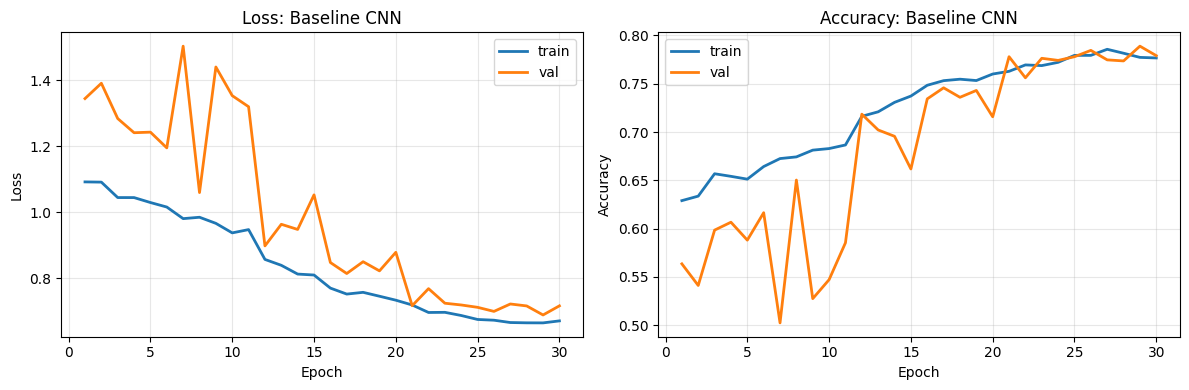

In [15]:
plots_dir = get_experiments_dir() / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plot_training_curves(
    history,
    title="Baseline CNN",
    save_path=plots_dir / "01_baseline_curves.png"
)

In [17]:
test_loss, test_acc = evaluate_on_test(model, test_ds)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"\nValidation accuracy (best, from history): "
      f"{max(history.history['val_accuracy']):.4f}")

Test loss:     0.6694
Test accuracy: 0.7861 (78.61%)

Validation accuracy (best, from history): 0.7889


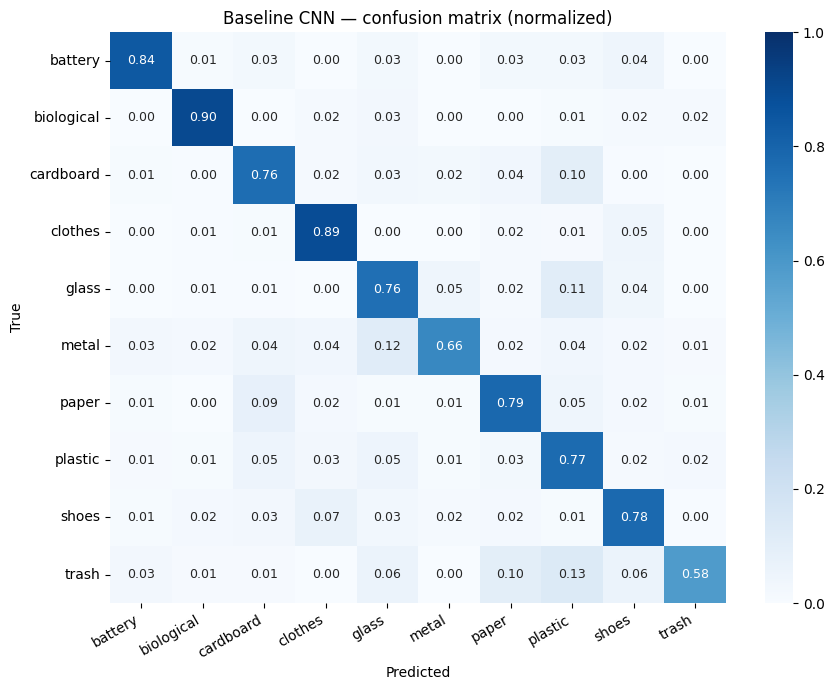

In [19]:
y_true, y_pred = collect_predictions(model, test_ds)

cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names=CLASS_NAMES,
    title="Baseline CNN — confusion matrix (normalized)",
    normalize=True,
    save_path=plots_dir / "01_baseline_confusion.png"
)

In [21]:
from sklearn.metrics import f1_score

report = print_classification_report(y_true, y_pred, CLASS_NAMES)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nMacro F1: {macro_f1:.4f}")

              precision    recall  f1-score   support

     battery      0.864     0.841     0.852       113
  biological      0.847     0.904     0.874       104
   cardboard      0.759     0.763     0.761       211
     clothes      0.866     0.894     0.880       283
       glass      0.779     0.758     0.768       260
       metal      0.780     0.662     0.716       139
       paper      0.789     0.785     0.787       200
     plastic      0.684     0.770     0.724       239
       shoes      0.779     0.779     0.779       217
       trash      0.750     0.582     0.655        67

    accuracy                          0.786      1833
   macro avg      0.790     0.774     0.780      1833
weighted avg      0.787     0.786     0.785      1833


Macro F1: 0.7797


In [22]:
import json

log_experiment({
    "experiment_name": "01_baseline_cnn",
    "model": "baseline_cnn_4block",
    "epochs": len(history.history['loss']),
    "batch_size": BATCH_SIZE,
    "optimizer": "adam",
    "learning_rate": LEARNING_RATE,
    "augmentation": "flip+brightness+contrast",
    "class_weights": "none",
    "train_acc": round(history.history['accuracy'][-1], 4),
    "val_acc": round(max(history.history['val_accuracy']), 4),
    "test_acc": round(test_acc, 4),
    "test_macro_f1": round(macro_f1, 4),
    "train_loss": round(history.history['loss'][-1], 4),
    "val_loss": round(min(history.history['val_loss']), 4),
    "test_loss": round(test_loss, 4),
    "training_time_sec": round(training_time, 1),
    "notes": "baseline reference, no class weights",
})

# Show the CSV
import pandas as pd
df = pd.read_csv(get_experiments_dir() / "results.csv")
print(df.to_string(index=False))

          timestamp experiment_name               model  epochs  batch_size optimizer  learning_rate             augmentation class_weights  train_acc  val_acc  test_acc  test_macro_f1  train_loss  val_loss  test_loss  training_time_sec                                notes
2026-05-16T17:27:12 01_baseline_cnn baseline_cnn_4block      30          32      adam          0.001 flip+brightness+contrast          none     0.7767   0.7889    0.7861         0.7797      0.6716    0.6895     0.6694              322.5 baseline reference, no class weights


## Findings

### Overall performance
- Baseline CNN achieved **78.61%** test accuracy and **0.780** macro F1 in 30 epochs
- Train (77.67%) and val (78.89%) are very close, indicating no overfitting
- EarlyStopping did not trigger — model was still improving at epoch 30
- Strong augmentation pipeline (flip + brightness + contrast) appears to act as
  an effective regularizer

### Strongest classes
- clothes (F1=0.880): largest class, visually homogeneous
- biological (F1=0.874): characteristic warm color profile makes it easy
  to distinguish (note: contradicts EDA prediction of high intra-class variance)
- battery (F1=0.852): distinctive cylindrical/rectangular shapes

### Weakest classes
- trash (F1=0.655): smallest class (67 test) AND highest intra-class variance —
  often confused with plastic (13%) and paper (10%) since real trash often
  contains those materials
- metal (F1=0.716): heavy confusion with glass (12%) — bottles and cans share
  shape and reflective surfaces
- plastic (F1=0.724): moderate confusion with glass and cardboard

### EDA predictions confirmed
The three confusion pairs predicted from visual inspection in EDA all appeared:
- paper ↔ cardboard (9% and 4% misclassification)
- glass ↔ metal (12% metal→glass, 5% glass→metal)
- plastic ↔ glass (11% glass→plastic, 5% plastic→glass)

### New observations
- trash class is "decomposed" by the model into its visual components
  (plastic packaging, paper napkins) rather than recognized as a unified concept
- Precision-recall asymmetry on trash (P=0.75, R=0.58) suggests the model
  under-predicts the minority class, motivating use of class weights in
  subsequent experiments

## Next steps

1. **Transfer Learning (ResNet50)**: expected to lift overall accuracy by 10-15 pp
   via ImageNet pre-trained semantic features
2. **Class weights**: should improve recall on minority classes (trash, biological)
   at potential small cost to majority classes
3. **EfficientNetV2S**: target ~95% to match published baseline on this dataset